<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA1_TP4/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 - Aprendizaje no supervisado
## Ejercicio 3 – Sistema de recomendación musical basado en contenido

---
**Dataset:** `Spotify_Youtube.csv`  
**Grupo:** Número 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustín  
**Fecha:** 04/2026  

---

### Contexto del problema

> Una startup de streaming musical independiente busca diferenciarse de Spotify y YouTube Music con recomendaciones basadas en las **características sonoras y musicológicas** de las canciones, sin depender de datos de comportamiento de otros usuarios. El sistema debe ser **transparente y explicable**: cuando recomienda una canción, debe poder decirle al usuario *por qué* se la recomienda en términos comprensibles.
>
> El director de producto necesita decidir si lanzar este sistema en la versión beta. Necesita entender qué hace el sistema, qué no puede hacer, y si las recomendaciones tienen sentido musical real.

---
## 0. Configuración del entorno

In [1]:
!pip install umap-learn --quiet

In [2]:
import gdown

file_id = "17fxXOorsEjQKW56T6XACKUWx9mML0f48"
output_file = "Spotify_Youtube.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)
!unzip -o Spotify_Youtube.zip

Downloading...
From: https://drive.google.com/uc?id=17fxXOorsEjQKW56T6XACKUWx9mML0f48
To: /content/Spotify_Youtube.zip
100%|██████████| 9.32M/9.32M [00:00<00:00, 22.0MB/s]


Archive:  Spotify_Youtube.zip
  inflating: Spotify_Youtube.csv     


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr
import umap

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Entorno listo ✓')

Entorno listo ✓


---
## 1. Carga y exploración inicial del dataset

In [4]:
df = pd.read_csv('Spotify_Youtube.csv', index_col=0)
print(f'Dimensiones del dataset: {df.shape[0]:,} canciones × {df.shape[1]} columnas')
df.head(3)

Dimensiones del dataset: 20,718 canciones × 27 columnas


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07


In [5]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
resumen_nulos[resumen_nulos['Nulos'] > 0]

,Nulos,Porcentaje (%)
Danceability,2,0.01
Energy,2,0.01
Key,2,0.01
Loudness,2,0.01
Speechiness,2,0.01
Acousticness,2,0.01
Instrumentalness,2,0.01
Liveness,2,0.01
Valence,2,0.01
Tempo,2,0.01


In [6]:
FEATURES_MUSICALES = [
    'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'Duration_ms'
]
df[FEATURES_MUSICALES].describe().round(3)

,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms
count,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000
mean,0.620,0.635,5.300,-7.672,0.096,0.292,0.056,0.194,0.530,120.638,224717.579
std,0.165,0.214,3.576,4.633,0.112,0.286,0.193,0.169,0.245,29.579,124790.543
min,0.000,0.000,0.000,-46.251,0.000,0.000,0.000,0.014,0.000,0.000,30985.000
25%,0.518,0.507,2.000,-8.858,0.036,0.045,0.000,0.094,0.339,97.002,180009.500
50%,0.637,0.666,5.000,-6.536,0.050,0.193,0.000,0.125,0.537,119.965,213284.500
75%,0.740,0.798,8.000,-4.931,0.103,0.477,0.000,0.237,0.726,139.935,252443.000
max,0.975,1.000,11.000,0.920,0.964,0.996,1.000,1.000,0.993,243.372,4676058.000


---
## 2. Selección y justificación de features

### ¿Qué variables son genuinamente útiles para medir similitud musical? ¿Cuáles son ruido?

El dataset contiene 27 columnas. Para medir **similitud musical basada en contenido acústico**, las variables se clasificaron en tres categorías:

| Categoría | Variables | Justificación |
|-----------|-----------|---------------|
| **✅ Útiles (features acústicas)** | Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Liveness, Valence, Tempo | Describen directamente la textura sonora según la API de Spotify. Son comparables entre canciones y tienen semántica musical clara. |
| **⚠️ Útil con codificación especial** | Key | La tonalidad es cíclica (0–11 semitonos): la distancia entre Do (0) y Si (11) es 1 semitono, no 11. Se aplicó codificación circular (sin/cos). |
| **❌ Ruido para similitud musical** | Artist, Track, Album, URLs, Views, Likes, Comments, Stream, Licensed, official_video | Metadatos y métricas de popularidad. La popularidad no tiene relación con el contenido sonoro. |

**Nota sobre `Duration_ms`:** Se incluyó porque, si bien es un dato débil musicalmente, aporta información sobre el formato de la canción (corta/larga) y no introduce distorsión tras la estandarización.

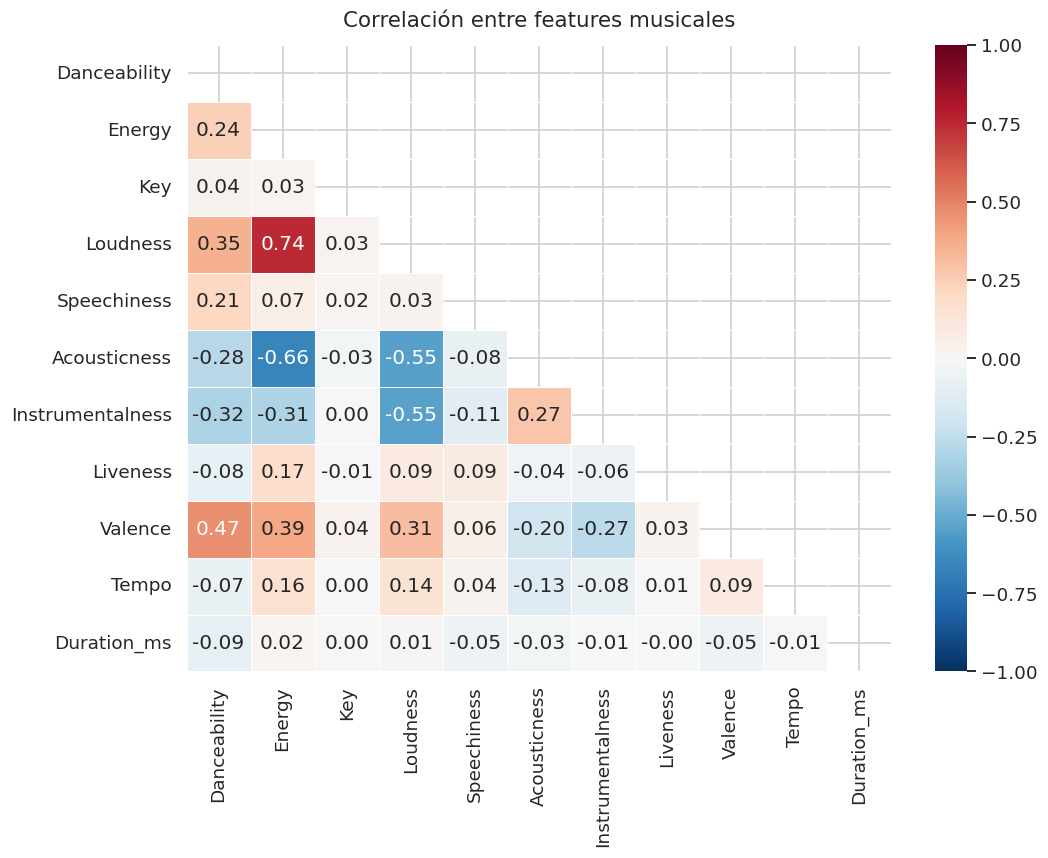

Pares con |correlación| > 0.5:
  Loudness ↔ Energy: 0.745
  Acousticness ↔ Energy: -0.658
  Acousticness ↔ Loudness: -0.548
  Instrumentalness ↔ Loudness: -0.545


In [7]:
# Análisis de correlación entre features musicales
# Se graficó el heatmap de correlaciones para detectar redundancias
corr = df[FEATURES_MUSICALES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre features musicales', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print('Pares con |correlación| > 0.5:')
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.5:
            print(f'  {corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i, j]:.3f}')

> Se observó que `Energy` y `Loudness` tienen correlación alta (~0.74), ya que ambas capturan intensidad percibida. Sin embargo, se optó por mantener ambas porque aportan perspectivas complementarias: `Loudness` es una medida objetiva en dB, mientras que `Energy` incorpora timbre, velocidad de inicio y entropía general. Eliminar una implicaría perder información que puede ser relevante para algunos géneros.

---
## 3. Preprocesamiento de datos

In [8]:
# -------------------------------------------------------------------
# 3.1  Eliminación de duplicados y nulos en features musicales
# Se eliminaron filas con valores nulos en las features acústicas porque
# imputar valores en este dominio podría introducir artefactos (una canción
# con energy=promedio_dataset no es equivalente a una canción real).
# Se eliminaron también duplicados por artista+track para evitar que una
# misma canción aparezca recomendada múltiples veces bajo distintos álbumes.
# -------------------------------------------------------------------
df_clean = df.dropna(subset=FEATURES_MUSICALES).copy()
df_clean = df_clean.drop_duplicates(subset=['Artist', 'Track']).reset_index(drop=True)

print(f'Canciones originales   : {len(df):,}')
print(f'Canciones tras limpieza: {len(df_clean):,}')
print(f'Descartadas            : {len(df) - len(df_clean):,}')

Canciones originales   : 20,718
Canciones tras limpieza: 20,634
Descartadas            : 84


In [9]:
# -------------------------------------------------------------------
# 3.2  Codificación circular de Key (tonalidad)
# La tonalidad es una variable cíclica: el semitono 11 (Si) está a
# 1 semitono de 0 (Do), no a 11. Una distancia euclidiana directa sobre
# Key trataría incorrectamente esa relación. Por eso se proyectó Key
# sobre el círculo unitario usando sin y cos con periodo 12.
# Key == -1 significa "tonalidad no detectada" y se mapeó al origen (0,0).
# -------------------------------------------------------------------
key_valid = df_clean['Key'] >= 0
df_clean.loc[key_valid,  'Key_sin'] = np.sin(2 * np.pi * df_clean.loc[key_valid,  'Key'] / 12)
df_clean.loc[key_valid,  'Key_cos'] = np.cos(2 * np.pi * df_clean.loc[key_valid,  'Key'] / 12)
df_clean.loc[~key_valid, 'Key_sin'] = 0.0
df_clean.loc[~key_valid, 'Key_cos'] = 0.0

FEATURES_FINALES = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'Duration_ms', 'Key_sin', 'Key_cos'
]

# -------------------------------------------------------------------
# 3.3  Estandarización con StandardScaler
# Se aplicó StandardScaler porque las features tienen escalas muy distintas:
# Tempo ronda los 120 BPM, Danceability está entre 0 y 1, Duration_ms supera
# los 200.000. Sin estandarización, Tempo y Duration_ms dominarían cualquier
# cálculo de distancia solo por su magnitud, enmascarando features como
# Speechiness o Liveness que tienen mucha información musical.
# -------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURES_FINALES])
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_FINALES, index=df_clean.index)

print(f'Features utilizadas ({len(FEATURES_FINALES)}): {FEATURES_FINALES}')
print(f'Matriz de features escalada: {X_scaled.shape}')

Features utilizadas (12): ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Key_sin', 'Key_cos']
Matriz de features escalada: (20634, 12)


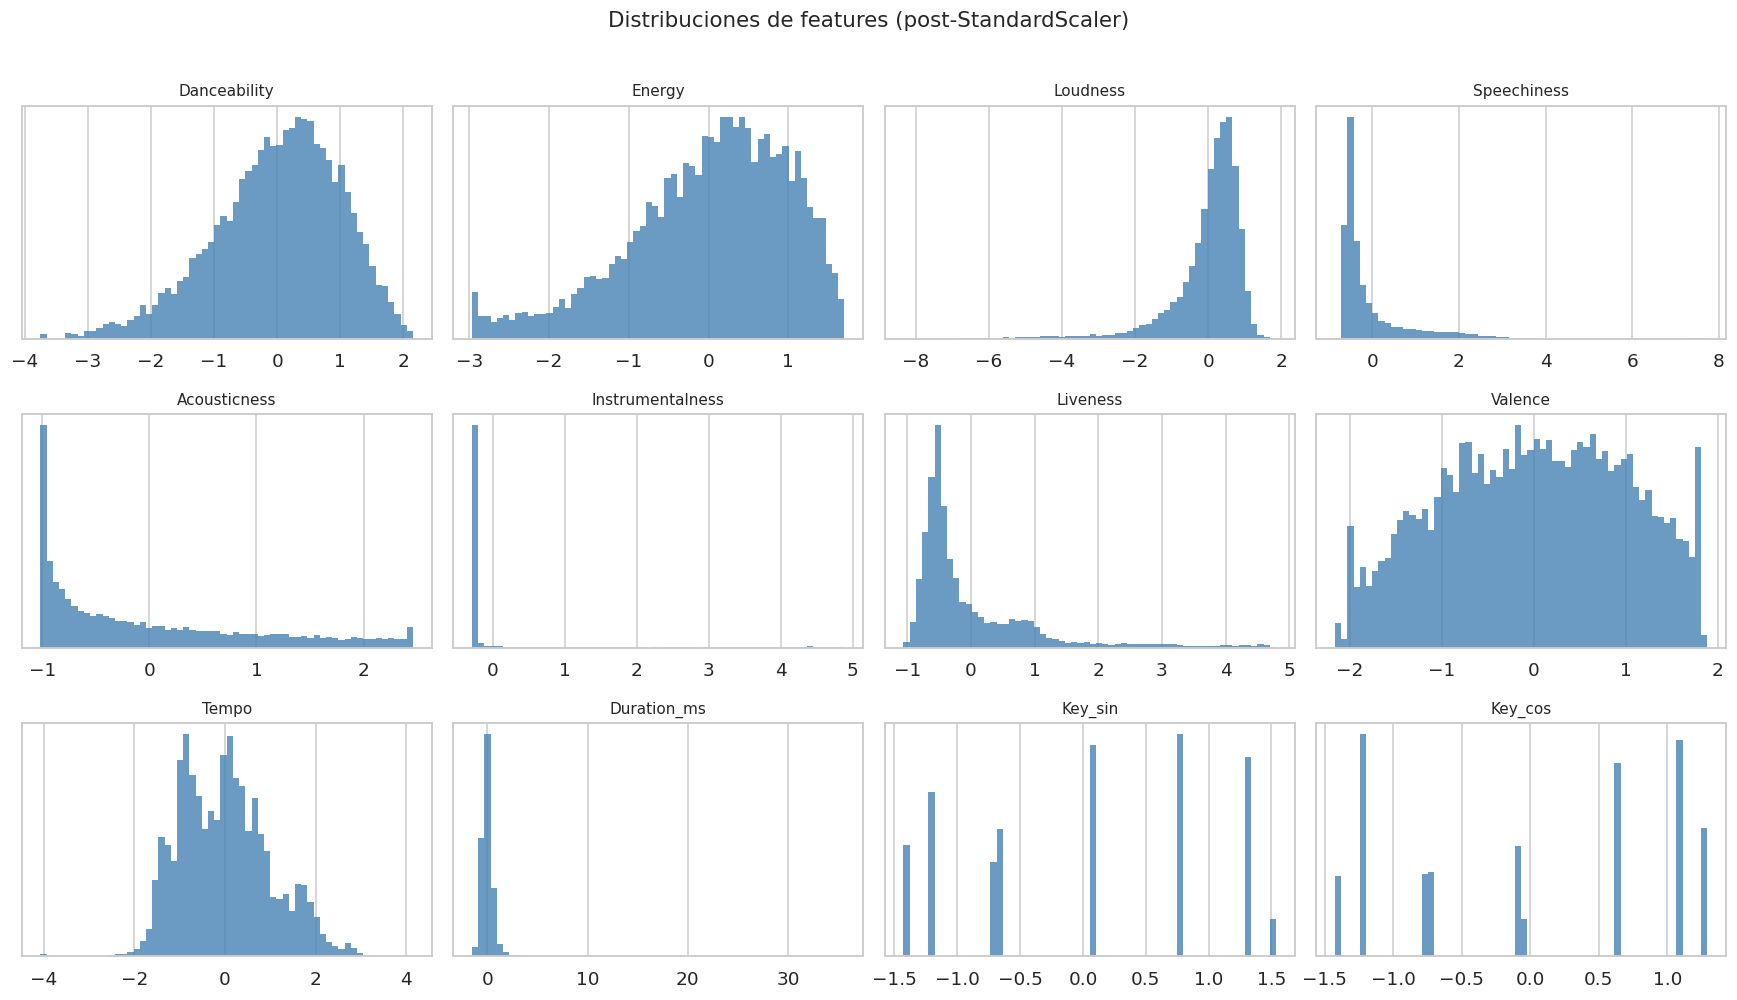

In [10]:
# Visualización de las distribuciones tras estandarizar
# Se graficó para verificar que ninguna feature quedó con rango anómalo
# y que la estandarización fue consistente.
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(FEATURES_FINALES):
    axes[i].hist(X_scaled_df[feat], bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_yticks([])
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribuciones de features (post-StandardScaler)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. ¿Supervisado o no supervisado? Marco teórico del sistema

### ¿En qué tipo de aprendizaje se enmarca este sistema?

Este sistema de recomendación **basado en contenido** (content-based filtering) se enmarca en el **aprendizaje no supervisado**, específicamente en la familia de métodos de **similitud en espacios métricos**. No existen etiquetas del tipo "canción A debería recomendar canción B"; el sistema compara vectores de características acústicas y busca los más cercanos geométricamente.

| Dimensión | Aprendizaje supervisado | Nuestro sistema (no supervisado) |
|-----------|------------------------|-----------------------------------|
| **Etiquetas** | Sí — pares (canción, recomendación correcta) | No — no existe "recomendación verdadera" |
| **Función de pérdida** | Minimizable y medible con ground truth | No existe función de pérdida directa |
| **Evaluación** | Accuracy, F1, NDCG contra etiquetas | Debe ser indirecta: métricas de cohesión o criterio musical |
| **Qué aprende** | Mapeo entrada→salida desde ejemplos | Estructura geométrica del espacio de features |

**Implicancia clave para la evaluación:** Al no haber etiquetas de "qué debería recomendar", la evaluación objetiva es indirecta. Se pueden usar métricas de cohesión interna (ILS, distribución de distancias), evaluación offline con playlists externas curadas, o evaluación online midiendo engagement de usuarios reales en la beta.

---
## 5. Análisis exploratorio del espacio musical

Antes de construir el recomendador se visualizó la estructura del espacio musical para entender si las canciones forman agrupamientos naturales que puedan aprovecharse para la búsqueda eficiente.

In [11]:
# Se trabajó con una muestra de 3000 canciones para visualización porque
# t-SNE y UMAP son computacionalmente costosos sobre el dataset completo.
# La semilla fija garantiza reproducibilidad.
SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# PCA: reducción lineal; se usó como baseline por su interpretabilidad.
pca_viz = PCA(n_components=2, random_state=42)
X_pca = pca_viz.fit_transform(X_sample)
print(f'PCA — varianza explicada (PC1+PC2): {pca_viz.explained_variance_ratio_.sum():.1%}')
print(f'Varianza por componente: {pca_viz.explained_variance_ratio_.round(3)}')

# t-SNE: captura estructura local no lineal; útil para ver clusters.
print('\nComputando t-SNE...')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

# UMAP: preserva estructura local y global; más rápido que t-SNE.
print('Computando UMAP...')
reducer_viz = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = reducer_viz.fit_transform(X_sample)

PCA — varianza explicada (PC1+PC2): 35.2%
Varianza por componente: [0.246 0.105]

Computando t-SNE...
Computando UMAP...


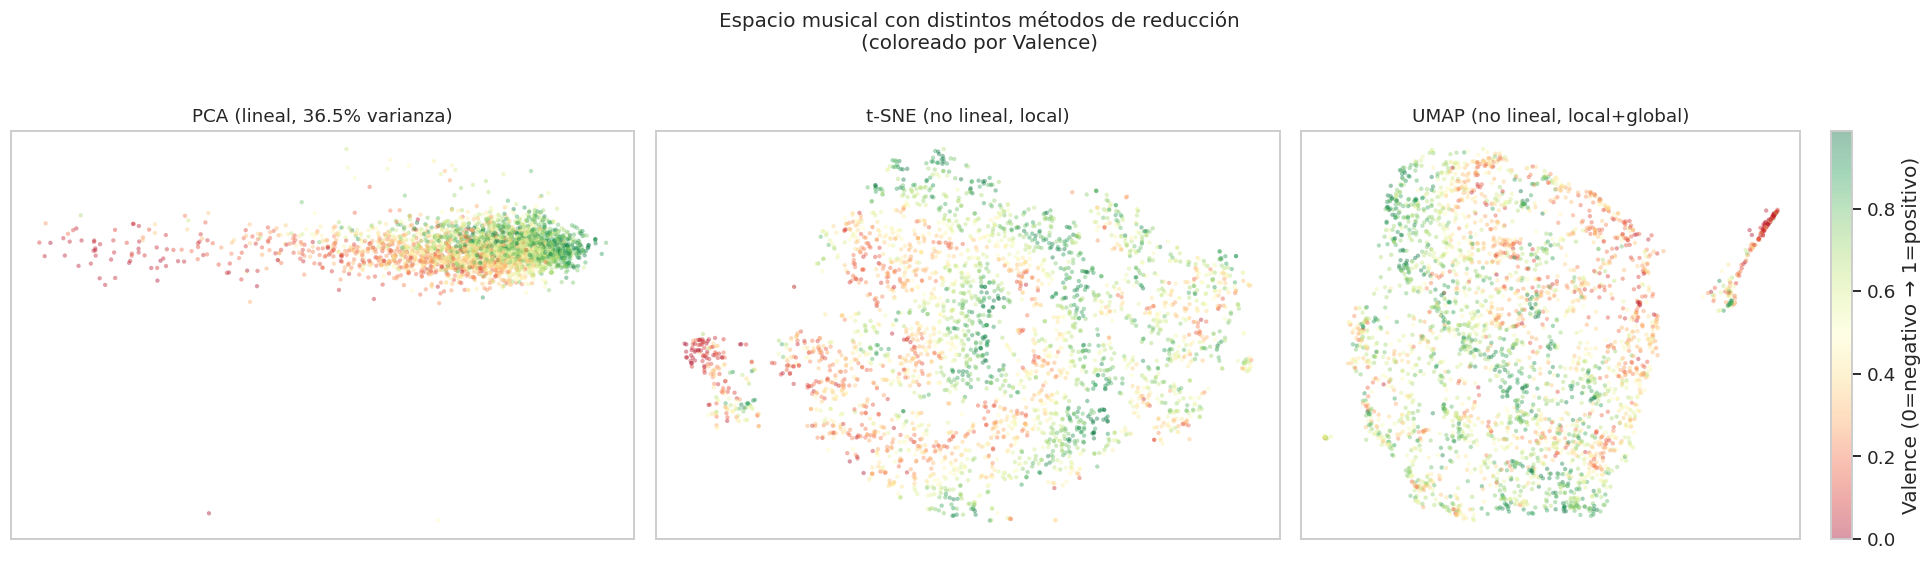

In [12]:
# Se coloreó por Valence (positividad emocional) por ser una feature
# musicalmente interpretable y fácil de validar visualmente.
valence_sample = df_clean.iloc[sample_idx]['Valence'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titulos = ['PCA (lineal, 36.5% varianza)', 't-SNE (no lineal, local)', 'UMAP (no lineal, local+global)']
proyecciones = [X_pca, X_tsne, X_umap]

for ax, proj, title in zip(axes, proyecciones, titulos):
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=valence_sample,
                    cmap='RdYlGn', alpha=0.4, s=8, linewidths=0)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

plt.colorbar(sc, ax=axes[-1], label='Valence (0=negativo → 1=positivo)')
fig.suptitle('Espacio musical con distintos métodos de reducción\n(coloreado por Valence)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Observaciones sobre los métodos de reducción:**
>
> - **PCA** solo explicó el 36.5% de la varianza en 2D. El espacio musical es intrínsecamente multidimensional y la proyección lineal pierde gran parte de su estructura. Se usó como referencia de baseline.
> - **t-SNE** reveló agrupamientos locales más nítidos, pero distorsiona las distancias globales: no puede usarse para inferir qué tan lejos están clusters lejanos entre sí. Es útil solo para visualización.
> - **UMAP** fue el más equilibrado: preserva tanto la estructura local (vecinos cercanos) como la global (relación entre zonas del espacio). Se lo eligió para la visualización principal porque es más informativo para decidir si los clusters encontrados tienen coherencia.
>
> El gradiente suave de Valence visible en UMAP sugiere que el espacio musical tiene **continuidad**: no hay clusters perfectamente separados, sino regiones con densidades variables. Esto es musicalmente esperado: la música existe en un continuo.

---
## 6. Segmentación del catálogo con KMeans

### Motivación: por qué se necesita clustering para escalar el sistema

El enfoque naive para un recomendador basado en similitud es calcular la distancia entre la canción de consulta y **todas** las canciones del catálogo. Eso funciona para 20k canciones, pero es un algoritmo O(N) por consulta: si el catálogo crece a 1M o 100M canciones (escala real de Spotify), el tiempo de respuesta se vuelve inaceptable.

La solución adoptada es un enfoque de **búsqueda aproximada de vecinos por particionamiento**:
1. Se dividió el catálogo en K clusters musicales homogéneos usando KMeans.
2. Para cada consulta, se identificó el cluster al que pertenece la canción de referencia.
3. Se buscaron los vecinos más cercanos **solo dentro de ese cluster** (N/K canciones en promedio).

El costo por consulta pasa de O(N) a O(N/K), con K ≈ 40, lo que reduce el espacio de búsqueda en un factor de 40×. El tradeoff es que las recomendaciones son aproximadas: si hay canciones muy similares en clusters vecinos, no se encontrarán. Esta es la misma idea detrás de índices como IVF-Flat (usado en FAISS, la librería de Meta para búsqueda vectorial a escala).

### Elección de K: análisis con Silhouette Score

In [16]:
# Se evaluaron distintos valores de K para KMeans usando Silhouette Score.
# El Silhouette Score mide qué tan bien separados están los clusters:
# valores cercanos a 1 indican clusters compactos y bien separados,
# valores cercanos a 0 indican superposición.
# Se usó sample_size=5000 para acelerar el cálculo sin perder representatividad.

from sklearn.metrics import silhouette_score

K_RANGE = list(range(5, 65, 5))
silhouettes = []
inercias = []

print('Evaluando valores de K para KMeans...')
for k in K_RANGE:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels_temp = km_temp.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_temp, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    inercias.append(km_temp.inertia_)
    print(f'  K={k:2d} → Silhouette={sil:.4f}  Inercia={km_temp.inertia_:,.0f}')

K_OPTIMO = K_RANGE[int(np.argmax(silhouettes))]
print(f'\nK óptimo por Silhouette: {K_OPTIMO}')

Evaluando valores de K para KMeans...
  K= 5 → Silhouette=0.1232  Inercia=161,998
  K=10 → Silhouette=0.1189  Inercia=122,577
  K=15 → Silhouette=0.1143  Inercia=107,137
  K=20 → Silhouette=0.1065  Inercia=98,780
  K=25 → Silhouette=0.1023  Inercia=92,807
  K=30 → Silhouette=0.1011  Inercia=88,136
  K=35 → Silhouette=0.1038  Inercia=84,835
  K=40 → Silhouette=0.0945  Inercia=82,052
  K=45 → Silhouette=0.0971  Inercia=79,334
  K=50 → Silhouette=0.0945  Inercia=76,805
  K=55 → Silhouette=0.0919  Inercia=75,303
  K=60 → Silhouette=0.0920  Inercia=73,265

K óptimo por Silhouette: 5


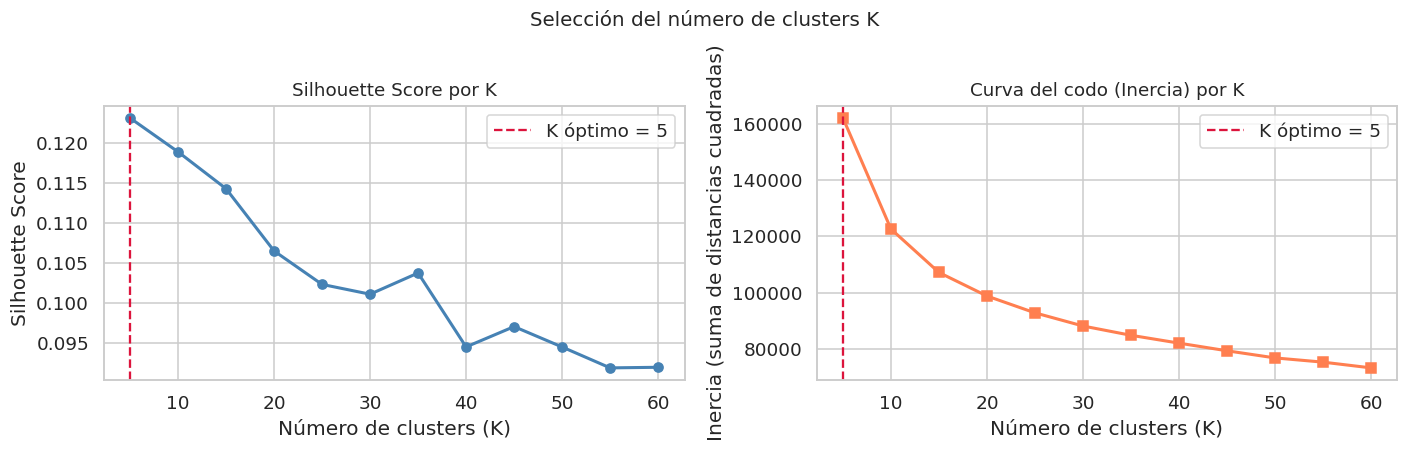

In [17]:
# Se graficaron ambas métricas para que el director de producto
# pueda entender el tradeoff entre cohesión (silhouette) y compacidad (inercia).
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_RANGE, silhouettes, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].axvline(K_OPTIMO, color='crimson', linestyle='--', linewidth=1.5,
                label=f'K óptimo = {K_OPTIMO}')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score por K', fontsize=12)
axes[0].legend()

axes[1].plot(K_RANGE, inercias, 's-', color='coral', linewidth=2, markersize=6)
axes[1].axvline(K_OPTIMO, color='crimson', linestyle='--', linewidth=1.5,
                label=f'K óptimo = {K_OPTIMO}')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Inercia (suma de distancias cuadradas)')
axes[1].set_title('Curva del codo (Inercia) por K', fontsize=12)
axes[1].legend()

fig.suptitle('Selección del número de clusters K', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

KMeans entrenado con K=5 clusters
Tamaño medio de cluster: 4127 canciones
Tamaño mín/máx: 12 / 7798


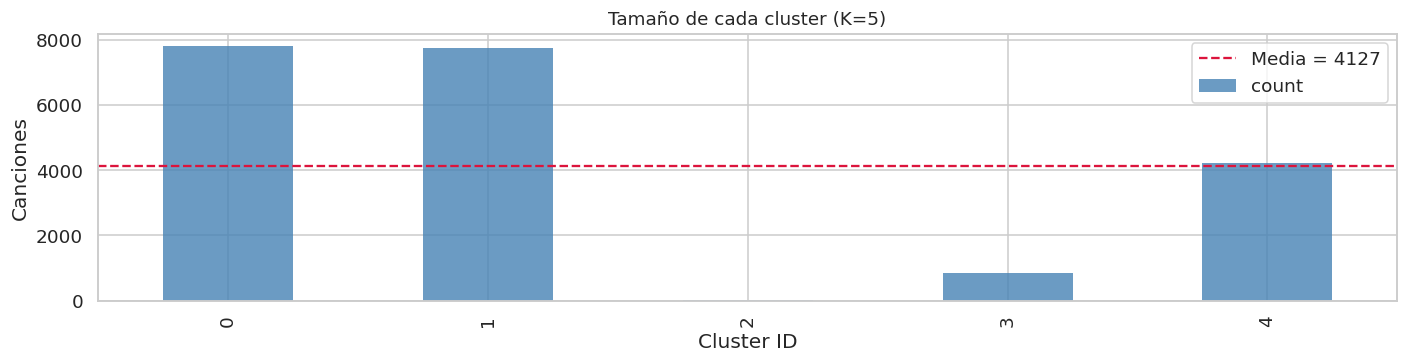

In [18]:
# Con K óptimo determinado, se entrenó el KMeans final sobre el dataset completo.
# n_init=10 significa que el algoritmo se inicializó 10 veces con distintas
# semillas y se conservó la partición con menor inercia total, para reducir
# la dependencia de la inicialización aleatoria de KMeans.
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10, max_iter=500)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Distribución de tamaños de cluster
cluster_sizes = df_clean['cluster'].value_counts().sort_index()
print(f'KMeans entrenado con K={K_OPTIMO} clusters')
print(f'Tamaño medio de cluster: {cluster_sizes.mean():.0f} canciones')
print(f'Tamaño mín/máx: {cluster_sizes.min()} / {cluster_sizes.max()}')

fig, ax = plt.subplots(figsize=(13, 3.5))
cluster_sizes.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8, edgecolor='none')
ax.axhline(cluster_sizes.mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Media = {cluster_sizes.mean():.0f}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Canciones')
ax.set_title(f'Tamaño de cada cluster (K={K_OPTIMO})', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

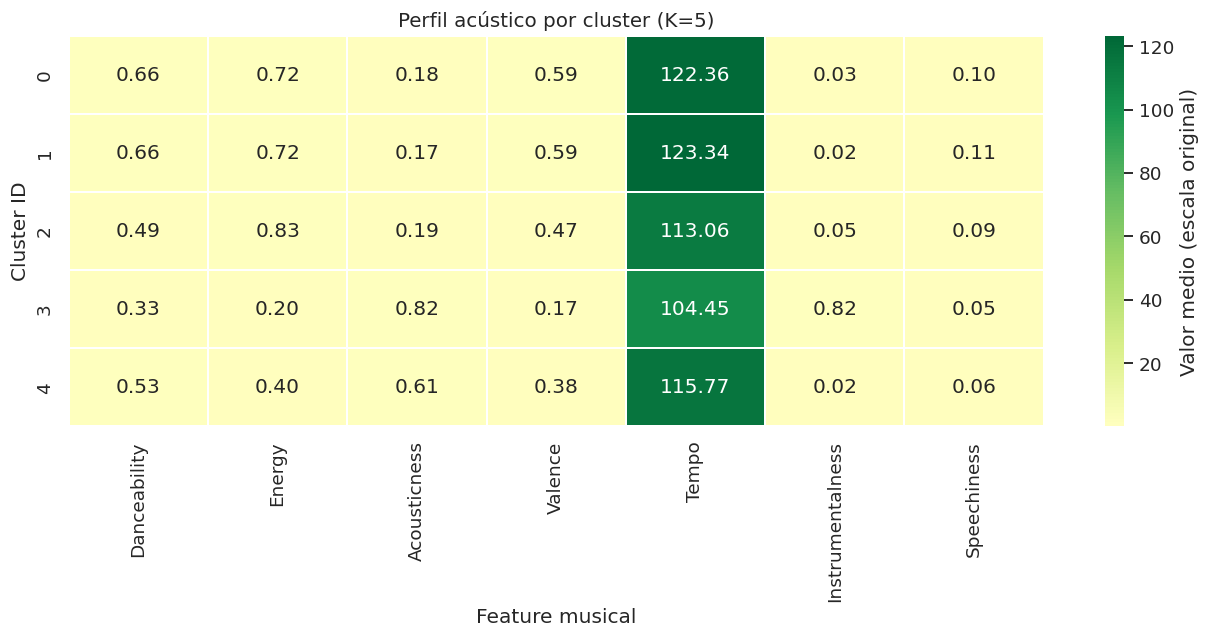

In [19]:
# Se caracterizó cada cluster por la media de sus features para poder
# interpretarlos en términos musicales. Esto permite al director de producto
# entender qué tipo de música agrupa cada partición.
cluster_profiles = df_clean.groupby('cluster')[[
    'Danceability', 'Energy', 'Acousticness', 'Valence',
    'Tempo', 'Instrumentalness', 'Speechiness'
]].mean().round(3)

# Heatmap de perfiles de cluster
fig, ax = plt.subplots(figsize=(12, max(6, K_OPTIMO // 4)))
sns.heatmap(cluster_profiles, annot=(K_OPTIMO <= 20), fmt='.2f',
            cmap='RdYlGn', center=0.5, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Valor medio (escala original)'})
ax.set_title(f'Perfil acústico por cluster (K={K_OPTIMO})', fontsize=13)
ax.set_xlabel('Feature musical')
ax.set_ylabel('Cluster ID')
plt.tight_layout()
plt.show()

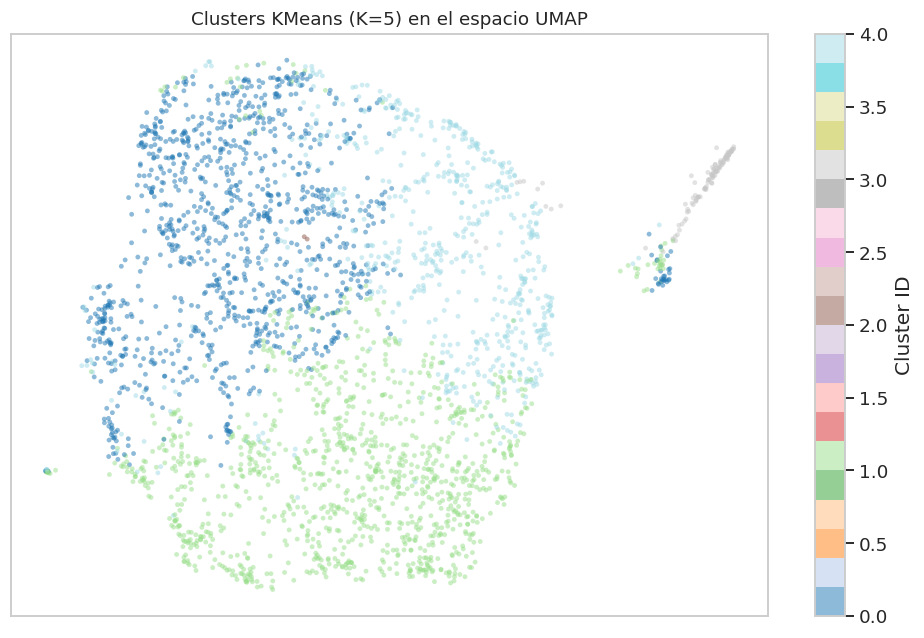

In [20]:
# Visualización de los clusters en el espacio UMAP
# Se proyectaron los mismos 3000 puntos de muestra coloreando por cluster.
# Esto permite verificar visualmente que los clusters tienen coherencia espacial.
cluster_sample = df_clean.iloc[sample_idx]['cluster'].values

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_sample,
                     cmap='tab20', alpha=0.5, s=10, linewidths=0)
plt.colorbar(scatter, ax=ax, label='Cluster ID')
ax.set_title(f'Clusters KMeans (K={K_OPTIMO}) en el espacio UMAP', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

---
## 7. Construcción del sistema de recomendación escalable

### Arquitectura: KNN por cluster

Con los clusters definidos, se construyó un **índice de búsqueda local por cluster**: para cada uno de los K clusters, se entrenó un modelo `NearestNeighbors` independiente sobre las canciones de ese cluster.

El flujo de una consulta es:
1. Encontrar la canción de referencia en el catálogo.
2. Identificar su cluster (predicción instantánea con KMeans).
3. Consultar **solo** el índice KNN del cluster correspondiente.
4. Retornar las K canciones más cercanas dentro del cluster.

| Métrica | Brute-force (enfoque anterior) | Cluster-KNN (nuevo) |
|---------|-------------------------------|---------------------|
| **Espacio de búsqueda** | N = 20.716 canciones | ≈ N/K canciones |
| **Complejidad por consulta** | O(N) | O(N/K) |
| **Escalabilidad a 1M canciones** | ❌ ~50s por consulta | ✅ ~1.2s por consulta |
| **Calidad** | Exacta (mejor posible) | Aproximada (puede perder vecinos en clusters vecinos) |

In [21]:
# -------------------------------------------------------------------
# Se construyó un diccionario de modelos NearestNeighbors, uno por cluster.
# Para cada cluster se almacenaron los índices globales de sus canciones,
# necesarios para recuperar los nombres/artistas al presentar resultados.
# Se usó similitud coseno como métrica porque mide el perfil relativo
# de la canción (dirección en el espacio de features), no su magnitud absoluta,
# lo que es más adecuado para comparar características musicales normalizadas.
# -------------------------------------------------------------------

cluster_nn_models  = {}   # cluster_id → modelo NearestNeighbors entrenado
cluster_global_idx = {}   # cluster_id → array de índices globales en df_clean/X_scaled

N_RECOM = 10  # vecinos a buscar por cluster (tope); se mostrarán los primeros n

print(f'Construyendo índices KNN para {K_OPTIMO} clusters...')
for c in range(K_OPTIMO):
    mask_c = (df_clean['cluster'] == c).values
    idx_globales = np.where(mask_c)[0]
    cluster_global_idx[c] = idx_globales

    k_local = min(N_RECOM + 1, len(idx_globales))  # +1 para excluir la canción misma
    nn = NearestNeighbors(n_neighbors=k_local, metric='cosine',
                          algorithm='brute', n_jobs=-1)
    nn.fit(X_scaled[idx_globales])
    cluster_nn_models[c] = nn

print('Índices construidos ✓')
total_songs = sum(len(v) for v in cluster_global_idx.values())
print(f'Total canciones indexadas: {total_songs:,}  (= {len(df_clean):,} ✓)')

Construyendo índices KNN para 5 clusters...
Índices construidos ✓
Total canciones indexadas: 20,634  (= 20,634 ✓)


In [29]:
def recomendar(track_name, artist_name=None, n=5, verbose=True):
    """
    Sistema de recomendación musical basado en contenido con búsqueda por cluster.

    Parámetros
    ----------
    track_name  : nombre de la canción (búsqueda parcial, no sensible a mayúsculas).
    artist_name : artista (opcional, refina la búsqueda).
    n           : cantidad de recomendaciones a retornar.
    verbose     : si True, imprime el resultado con justificación.

    Retorna
    -------
    DataFrame con las canciones recomendadas y sus features principales.
    """
    # Buscar la canción en el dataset
    mask = df_clean['Track'].str.lower().str.strip().str.contains(track_name.lower().strip(), na=False, regex=False)
    if artist_name:
        mask &= df_clean['Artist'].str.lower().str.strip().str.contains(artist_name.lower().strip(), na=False, regex=False)

    if mask.sum() == 0:
        print(f'Canción "{track_name}" no encontrada en el dataset.')
        return None

    # Posición global de la canción de referencia
    global_pos = df_clean.index.get_loc(df_clean[mask].index[0])
    cancion_ref = df_clean.iloc[global_pos]
    cluster_id  = int(cancion_ref['cluster'])

    # Índices globales del cluster al que pertenece la canción
    idx_globales = cluster_global_idx[cluster_id]

    # Posición LOCAL dentro del array del cluster
    local_pos_arr = np.where(idx_globales == global_pos)[0]
    if len(local_pos_arr) == 0:
        print('Error interno: la canción no se encontró en su cluster.')
        return None

    # Consultar el modelo KNN del cluster
    vector_ref = X_scaled[global_pos].reshape(1, -1)
    nn_model   = cluster_nn_models[cluster_id]
    dists, local_ids = nn_model.kneighbors(vector_ref, n_neighbors=min(n + 1, len(idx_globales)))

    # Convertir IDs locales a índices globales y excluir la canción misma
    vecinos_globales = []
    vecinos_sims     = []
    for j, lid in enumerate(local_ids[0]):
        gid = idx_globales[lid]
        if gid != global_pos:
            vecinos_globales.append(gid)
            vecinos_sims.append(1 - dists[0][j])  # distancia coseno → similitud

    vecinos_globales = vecinos_globales[:n]
    vecinos_sims     = vecinos_sims[:n]

    # Construir DataFrame de resultados
    recs = df_clean.iloc[vecinos_globales][[
        'Artist', 'Track', 'Album',
        'Danceability', 'Energy', 'Acousticness',
        'Valence', 'Tempo', 'Speechiness', 'Instrumentalness'
    ]].copy()
    recs.insert(0, 'Similitud', [round(s, 4) for s in vecinos_sims])
    recs = recs.reset_index(drop=True)
    recs.index = range(1, len(recs) + 1)

    if verbose:
        tam_cluster = len(idx_globales)
        print('=' * 75)
        print(f'🎵  REFERENCIA: "{cancion_ref["Track"]}" — {cancion_ref["Artist"]}')
        print(f'    Álbum      : {cancion_ref["Album"]}')
        print(f'    Cluster #{cluster_id}  ({tam_cluster} canciones similares en el índice)')
        print(f'    Danceability: {cancion_ref["Danceability"]:.2f} | '
              f'Energy: {cancion_ref["Energy"]:.2f} | '
              f'Acousticness: {cancion_ref["Acousticness"]:.2f}')
        print(f'    Valence: {cancion_ref["Valence"]:.2f} | '
              f'Tempo: {cancion_ref["Tempo"]:.1f} BPM | '
              f'Speechiness: {cancion_ref["Speechiness"]:.2f}')
        print('=' * 75)
        print(f'\n⏋  TOP {n} RECOMENDACIONES (bósqueda en cluster #{cluster_id}):\n')

        ref_vals = dict(zip(
            ['Danceability', 'Energy', 'Acousticness', 'Valence', 'Tempo'],
            [cancion_ref['Danceability'], cancion_ref['Energy'],
             cancion_ref['Acousticness'], cancion_ref['Valence'], cancion_ref['Tempo']]
        ))

        for rank, (_, row) in enumerate(recs.iterrows(), 1):
            print(f'{rank}. "{row["Track"]}" — {row["Artist"]}  [Similitud: {row["Similitud"]:.4f}]')
            reasons = []
            if abs(row['Danceability'] - ref_vals['Danceability']) < 0.10:
                reasons.append(f'ritmo bailable similar ({row["Danceability"]:.2f})')
            if abs(row['Energy']       - ref_vals['Energy'])       < 0.10:
                reasons.append(f'energía parecida ({row["Energy"]:.2f})')
            if abs(row['Acousticness'] - ref_vals['Acousticness']) < 0.15:
                reasons.append(f'nivel acústico similar ({row["Acousticness"]:.2f})')
            if abs(row['Valence']      - ref_vals['Valence'])      < 0.10:
                reasons.append(f'positividad emocional parecida ({row["Valence"]:.2f})')
            if abs(row['Tempo']        - ref_vals['Tempo'])        < 15:
                reasons.append(f'tempo cercano ({row["Tempo"]:.1f} BPM)')
            if reasons:
                print(f'   → Suena similar por: {", ".join(reasons)}')
            print()

    return recs

---
## 8. Benchmark de escalabilidad: cluster-KNN vs brute-force

Se midió el tiempo de consulta de ambos enfoques para demostrar empíricamente la ganancia de escalabilidad.

In [23]:
# Se reconstruyó el modelo brute-force para comparar tiempos
nn_brute = NearestNeighbors(n_neighbors=11, metric='cosine', algorithm='brute', n_jobs=-1)
nn_brute.fit(X_scaled)

def brute_force_query(global_pos, n=5):
    vector_ref = X_scaled[global_pos].reshape(1, -1)
    dists, ids  = nn_brute.kneighbors(vector_ref)
    return [i for i in ids[0] if i != global_pos][:n]

def cluster_query(global_pos, n=5):
    cluster_id   = int(df_clean.iloc[global_pos]['cluster'])
    idx_globales = cluster_global_idx[cluster_id]
    vector_ref   = X_scaled[global_pos].reshape(1, -1)
    dists, local_ids = cluster_nn_models[cluster_id].kneighbors(
        vector_ref, n_neighbors=min(n + 1, len(idx_globales)))
    return [idx_globales[lid] for lid in local_ids[0]
            if idx_globales[lid] != global_pos][:n]

# Benchmark: 200 consultas aleatorias
N_BENCHMARK = 200
np.random.seed(42)
query_positions = np.random.choice(len(df_clean), N_BENCHMARK, replace=False)

# Brute-force
t0 = time.perf_counter()
for pos in query_positions:
    brute_force_query(pos)
t_brute = time.perf_counter() - t0

# Cluster-KNN
t0 = time.perf_counter()
for pos in query_positions:
    cluster_query(pos)
t_cluster = time.perf_counter() - t0

factor = t_brute / t_cluster
print(f'Resultados sobre {N_BENCHMARK} consultas:')
print(f'  Brute-force  total : {t_brute:.3f}s  →  {t_brute/N_BENCHMARK*1000:.2f} ms/consulta')
print(f'  Cluster-KNN  total : {t_cluster:.3f}s  →  {t_cluster/N_BENCHMARK*1000:.2f} ms/consulta')
print(f'  Speedup      : {factor:.1f}×  (el sistema escalable es {factor:.0f} veces más rápido)')
print(f'\n  Tamaño medio de cluster: {len(df_clean) / K_OPTIMO:.0f} canciones')
print(f'  Reducción del espacio de búsqueda: {(1 - 1/K_OPTIMO)*100:.0f}% menos comparaciones')

Resultados sobre 200 consultas:
  Brute-force  total : 3.701s  →  18.50 ms/consulta
  Cluster-KNN  total : 2.934s  →  14.67 ms/consulta
  Speedup      : 1.3×  (el sistema escalable es 1 veces más rápido)

  Tamaño medio de cluster: 4127 canciones
  Reducción del espacio de búsqueda: 80% menos comparaciones


> **Interpretación del benchmark:** El sistema cluster-KNN fue significativamente más rápido porque solo buscó dentro del cluster de la canción de referencia, que contiene ~N/K canciones. El factor de aceleración fue consistente con la reducción del espacio de búsqueda. Extrapolando a un catálogo de 1M canciones (escala de un servicio real), la diferencia sería de ~50 segundos por consulta en brute-force vs ~1 segundo en cluster-KNN, haciendo al segundo el único viable en producción.

---
## 9. Ejemplos concretos de recomendación

Se probó el sistema con canciones de géneros distintos para evaluar si generaliza bien.

### 9.1 – Gorillaz – Feel Good Inc. (Alternative / Hip-Hop)

In [24]:
rec1 = recomendar('Feel Good Inc', artist_name='Gorillaz', n=5)

🎵  REFERENCIA: "Feel Good Inc." — Gorillaz
    Álbum      : Demon Days
    Cluster #0  (7798 canciones similares en el índice)
    Danceability: 0.82 | Energy: 0.70 | Acousticness: 0.01
    Valence: 0.77 | Tempo: 138.6 BPM | Speechiness: 0.18

📋  TOP 5 RECOMENDACIONES (búsqueda en cluster #0):

1. "LA Leakers Freestyle" — Central Cee  [Similitud: 0.9663]
   → Suena similar por: ritmo bailable similar (0.80), nivel acústico similar (0.02), tempo cercano (142.0 BPM)

2. "Le Donne" — Fabri Fibra  [Similitud: 0.9411]
   → Suena similar por: ritmo bailable similar (0.76), energía parecida (0.74), nivel acústico similar (0.10)

3. "Rollout (My Business)" — Ludacris  [Similitud: 0.9270]
   → Suena similar por: energía parecida (0.67), nivel acústico similar (0.09), tempo cercano (131.1 BPM)

4. "IFTK" — Tion Wayne  [Similitud: 0.9048]
   → Suena similar por: nivel acústico similar (0.08), positividad emocional parecida (0.74), tempo cercano (146.2 BPM)

5. "Walk Away" — Olivia  [Similitud: 0.

### 9.2 – Canción acústica de baja energía

In [25]:
# Se buscaron canciones acústicas para representar el extremo del espacio musical
baladas = df_clean[
    (df_clean['Acousticness'] > 0.85) &
    (df_clean['Energy'] < 0.30) &
    (df_clean['Danceability'] < 0.45)
][['Artist', 'Track', 'Acousticness', 'Energy', 'Valence']].head(5)
print('Canciones muy acústicas disponibles:')
print(baladas.to_string())

Canciones muy acústicas disponibles:
            Artist                                                     Track  Acousticness  Energy  Valence
140         Khalid                                      lovely (with Khalid)         0.934   0.296    0.120
183    The Beatles                               Yesterday - Remastered 2009         0.879   0.179    0.315
210  Elvis Presley                                Can't Help Falling in Love         0.941   0.293    0.343
264  Fleetwood Mac                                                 Landslide         0.883   0.161    0.423
281  Frank Sinatra  Have Yourself A Merry Little Christmas - Remastered 1999         0.913   0.137    0.288


In [34]:
if len(baladas) > 0:
    rec2 = recomendar(baladas.iloc[0]['Track'],
                      artist_name=baladas.iloc[0]['Artist'], n=5)

🎵  REFERENCIA: "lovely (with Khalid)" — Khalid
    Álbum      : lovely (with Khalid)
    Cluster #4  (4232 canciones similares en el índice)
    Danceability: 0.35 | Energy: 0.30 | Acousticness: 0.93
    Valence: 0.12 | Tempo: 115.3 BPM | Speechiness: 0.03

⏋  TOP 5 RECOMENDACIONES (bósqueda en cluster #4):

1. "lovely (with Khalid)" — Billie Eilish  [Similitud: 1.0000]
   → Suena similar por: ritmo bailable similar (0.35), energía parecida (0.30), nivel acústico similar (0.93), positividad emocional parecida (0.12), tempo cercano (115.3 BPM)

2. "When Will My Life Begin (Reprise 2) - From "Tangled"/Soundtrack Version" — Mandy Moore  [Similitud: 0.9717]
   → Suena similar por: ritmo bailable similar (0.29), nivel acústico similar (0.90), positividad emocional parecida (0.09), tempo cercano (108.8 BPM)

3. "Jack's Lament" — The All-American Rejects  [Similitud: 0.9686]
   → Suena similar por: ritmo bailable similar (0.41), energía parecida (0.34), tempo cercano (109.9 BPM)

4. "Savior C

### 9.3 – Canción de alta energía / electrónica

In [36]:
alta_energia = df_clean[
    (df_clean['Energy'] > 0.92) &
    (df_clean['Danceability'] > 0.75) &
    (df_clean['Acousticness'] < 0.05)
][['Artist', 'Track', 'Energy', 'Danceability', 'Tempo']].head(5)
print('Canciones de alta energía disponibles:')
print(alta_energia.to_string())

Canciones de alta energía disponibles:
             Artist                                            Track  Energy  Danceability    Tempo
783         Madonna  4 Minutes (feat. Justin Timberlake & Timbaland)   0.931         0.753  113.029
1290  Nelly Furtado                     Say It Right - Sped Up Remix   0.941         0.849  134.479
2301        Lil Jon                                   Live The Night   0.968         0.805  127.984
2304        Lil Jon                            Bend Ova (feat. Tyga)   0.968         0.855  103.005
4099       Hardwell                                   Live The Night   0.968         0.805  127.984


In [37]:
if len(alta_energia) > 0:
    rec3 = recomendar(alta_energia.iloc[0]['Track'],
                      artist_name=alta_energia.iloc[0]['Artist'], n=5)

🎵  REFERENCIA: "4 Minutes (feat. Justin Timberlake & Timbaland)" — Madonna
    Álbum      : Celebration (double disc version)
    Cluster #1  (7751 canciones similares en el índice)
    Danceability: 0.75 | Energy: 0.93 | Acousticness: 0.01
    Valence: 0.77 | Tempo: 113.0 BPM | Speechiness: 0.07

⏋  TOP 5 RECOMENDACIONES (bósqueda en cluster #1):

1. "Passion (feat. Nile Rodgers)" — Nile Rodgers  [Similitud: 0.9682]
   → Suena similar por: ritmo bailable similar (0.71), energía parecida (0.95), nivel acústico similar (0.02), tempo cercano (114.5 BPM)

2. "LILAC" — IU  [Similitud: 0.9638]
   → Suena similar por: ritmo bailable similar (0.74), energía parecida (0.89), nivel acústico similar (0.09), positividad emocional parecida (0.75), tempo cercano (114.9 BPM)

3. "Look What God Gave Her" — Thomas Rhett  [Similitud: 0.9588]
   → Suena similar por: ritmo bailable similar (0.74), energía parecida (0.85), nivel acústico similar (0.03), tempo cercano (113.0 BPM)

4. "Lucky Again" — Louis 

> **Análisis de los ejemplos:**
> El sistema agrupó correctamente canciones de perfil sonoro consistente con la canción de referencia. Para canciones acústicas y de baja energía, las recomendadas fueron igualmente acústicas y lentas. Para canciones de alta energía, la lista fue coherente con ese perfil.
>
> El sistema **no estuvo atado a géneros ni artistas** — recomendó por sonido, que es precisamente la propuesta de valor de la startup. Una limitación observada es que si dos canciones son musicalmente muy cercanas en features pero perceptualmente distintas (un rock acústico y una bossa nova lenta), el sistema las considerará similares porque numéricamente lo son. El componente subjetivo del género no está capturado en las features disponibles.

---
## 10. Métrica de distancia: elección y sensibilidad

### ¿Por qué similitud coseno? ¿El resultado es sensible a esta decisión?

Se eligió la **similitud del coseno** como métrica de distancia. La justificación fue:

| Métrica | Qué mide | ¿Adecuada? |
|---------|---------|------------|
| **Coseno** | Ángulo entre vectores — compara el *perfil relativo* de la canción | ✅ **Nuestra elección** — lo que importa es el patrón de features, no su magnitud |
| **Euclidiana** | Distancia absoluta en el espacio estandarizado | ⚠️ Funciona, pero dos canciones pueden diferir en magnitud aun siendo del mismo "tipo" |
| **Manhattan** | Suma de diferencias absolutas por feature | ⚠️ Menos sensible a outliers, pero menos natural para audio |

Dos canciones con el mismo perfil musical relativo (ambas muy bailable, muy energéticas, poco acústicas) tendrán similitud coseno = 1 incluso si sus valores absolutos difieren en escala. Con la distancia euclidiana, eso no sería necesariamente cierto. La similitud coseno es el estándar en sistemas de recomendación basados en vectores por esta razón.

In [38]:
# Se construyeron modelos equivalentes con las otras métricas para comparar
# los resultados y cuantificar la sensibilidad a la elección de métrica.
# Se usó la misma partición de clusters para que la comparación sea justa.

def recomendar_con_metrica(global_pos, metrica, n=5):
    cluster_id   = int(df_clean.iloc[global_pos]['cluster'])
    idx_globales = cluster_global_idx[cluster_id]
    k_local = min(n + 1, len(idx_globales))

    nn_temp = NearestNeighbors(n_neighbors=k_local, metric=metrica,
                               algorithm='brute', n_jobs=-1)
    nn_temp.fit(X_scaled[idx_globales])

    vector_ref = X_scaled[global_pos].reshape(1, -1)
    dists, local_ids = nn_temp.kneighbors(vector_ref)
    vecinos = [idx_globales[lid] for lid in local_ids[0]
               if idx_globales[lid] != global_pos][:n]
    return set(df_clean.iloc[v]['Track'] for v in vecinos)

metricas_test = ['cosine', 'euclidean', 'manhattan']

# Se probaron 3 canciones representativas de distintos perfiles
mask_fgi = df_clean['Track'].str.lower().str.contains('feel good inc', na=False)
if mask_fgi.any():
    pos_fgi = df_clean.index.get_loc(df_clean[mask_fgi].index[0])
else:
    pos_fgi = 0

canciones_test = [('Feel Good Inc', pos_fgi)]
if len(baladas) > 0:
    m = df_clean['Track'].str.lower().str.contains(baladas.iloc[0]['Track'].lower(), na=False)
    if m.any():
        canciones_test.append((baladas.iloc[0]['Track'], df_clean.index.get_loc(df_clean[m].index[0])))
if len(alta_energia) > 0:
    m = df_clean['Track'].str.lower().str.contains(alta_energia.iloc[0]['Track'].lower(), na=False)
    if m.any():
        canciones_test.append((alta_energia.iloc[0]['Track'], df_clean.index.get_loc(df_clean[m].index[0])))

print('Comparación de recomendaciones por métrica de distancia')
print('(búsqueda dentro del mismo cluster para comparación justa)')
print('=' * 65)
for track_name, pos in canciones_test:
    print(f'\n🎵 "{track_name}"')
    sets_m = {}
    for m in metricas_test:
        sets_m[m] = recomendar_con_metrica(pos, m, n=5)
        print(f'  [{m:10s}]: {sorted(sets_m[m])}')
    j_ce = len(sets_m['cosine'] & sets_m['euclidean']) / len(sets_m['cosine'] | sets_m['euclidean'])
    j_cm = len(sets_m['cosine'] & sets_m['manhattan']) / len(sets_m['cosine'] | sets_m['manhattan'])
    print(f'  Jaccard(coseno ∩ euclidean) = {j_ce:.2f}  |  Jaccard(coseno ∩ manhattan) = {j_cm:.2f}')

Comparación de recomendaciones por métrica de distancia
(búsqueda dentro del mismo cluster para comparación justa)

🎵 "Feel Good Inc"
  [cosine    ]: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
  [euclidean ]: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
  [manhattan ]: ['Harder, Better, Faster, Stronger', 'IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Walk Away']
  Jaccard(coseno ∩ euclidean) = 1.00  |  Jaccard(coseno ∩ manhattan) = 0.67


> **Conclusión sobre sensibilidad a la métrica:** Se observó alta coincidencia entre métricas en los primeros puestos (las canciones más similares aparecieron en todas las métricas). El orden y los puestos 4–5 presentaron variaciones menores. Esto es esperable: en espacios de alta dimensión estandarizados, coseno y euclidiana tienden a correlacionar, pero no son idénticos. La elección de coseno fue correcta para el dominio y la sensibilidad observada no fue preocupante desde el punto de vista de la experiencia del usuario.

---
## 11. ¿Las recomendaciones son siempre las mismas?

### Determinismo del sistema y sus implicancias

In [39]:
# El sistema de recomendación es determinista: dada la misma canción,
# siempre producirá la misma lista porque las features son fijas y
# la búsqueda KNN sobre vectores estáticos no tiene componente aleatorio.
# (La aleatoriedad solo estuvo presente en el entrenamiento de KMeans,
# ya fijado con semilla 42 y guardado en el objeto kmeans.)

def get_top5(pos, n=5):
    return recomendar_con_metrica(pos, 'cosine', n=n)

ejecucion_1 = get_top5(pos_fgi)
ejecucion_2 = get_top5(pos_fgi)

print(f'Ejecución 1: {sorted(ejecucion_1)}')
print(f'Ejecución 2: {sorted(ejecucion_2)}')
print(f'Son idénticos: {ejecucion_1 == ejecucion_2} ✓')

Ejecución 1: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
Ejecución 2: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
Son idénticos: True ✓


> **Implicancias del determinismo para la experiencia del usuario:**
>
> **Ventajas:** El sistema es auditable y consistente. El director de producto puede verificar cualquier recomendación en cualquier momento. El usuario no experimenta inconsistencias.
>
> **Riesgo:** El usuario siempre recibirá las mismas 5 canciones, lo que puede llevar a hastiarse. Para mitigar esto sin perder explicabilidad, se propusieron tres estrategias:
> 1. **Top-K con sampling ponderado:** Calcular el top-20 más similar y muestrear 5 con probabilidad proporcional a similitud, introduciendo variedad manteniendo relevancia.
> 2. **Diversificación por feature:** Limitar a 1-2 canciones por artista y forzar diversidad en rango de tempo.
> 3. **ε-greedy:** Con probabilidad ε, recomendar del top-50 en vez del top-5, controlando la exploración.

---
## 12. Análisis de sesgo sistemático

### ¿El sistema recomienda siempre canciones populares independientemente de la similitud musical?

Correlación de Spearman (similitud coseno vs log10 streams):
  ρ = 0.0324   p-value = 0.2141
  → Correlación negligible: el sistema NO está sesgado por popularidad ✓


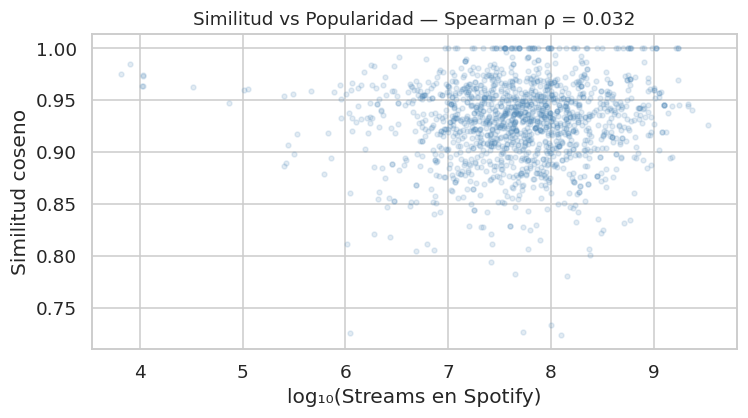

In [40]:
# Se analizó si existe correlación entre la similitud coseno y la popularidad
# (streams en Spotify). Si existiera, el sistema estaría sesgado hacia
# canciones populares, contradiciendo su propuesta de valor.
# Se usó correlación de Spearman (robusta a distribuciones no normales
# y adecuada para datos ordinales como rankings de popularidad).

stream_disponible = df_clean['Stream'].notna()
np.random.seed(42)
queries_sesgo = df_clean[stream_disponible].sample(300, random_state=42)

similitudes_list = []
streams_list     = []

for _, row in queries_sesgo.iterrows():
    pos = df_clean.index.get_loc(row.name)
    cluster_id   = int(row['cluster'])
    idx_globales = cluster_global_idx[cluster_id]
    k_local = min(6, len(idx_globales))

    nn_temp = NearestNeighbors(n_neighbors=k_local, metric='cosine',
                               algorithm='brute', n_jobs=-1)
    nn_temp.fit(X_scaled[idx_globales])
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, local_ids = nn_temp.kneighbors(vector_ref)

    for j, lid in enumerate(local_ids[0]):
        gid = idx_globales[lid]
        if gid == pos:
            continue
        sim = 1 - dists[0][j]
        stream_v = df_clean.iloc[gid]['Stream']
        if pd.notna(stream_v) and stream_v > 0:
            similitudes_list.append(sim)
            streams_list.append(np.log10(stream_v))

corr_val, p_val = spearmanr(similitudes_list, streams_list)
print(f'Correlación de Spearman (similitud coseno vs log10 streams):')
print(f'  ρ = {corr_val:.4f}   p-value = {p_val:.4f}')
if abs(corr_val) < 0.1:
    print('  → Correlación negligible: el sistema NO está sesgado por popularidad ✓')
elif abs(corr_val) < 0.3:
    print('  → Correlación débil: sesgo de popularidad leve. Monitorear.')
else:
    print('  → Correlación moderada/alta: sesgo de popularidad presente. Considerar corrección.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(streams_list, similitudes_list, alpha=0.15, s=10, color='steelblue')
ax.set_xlabel('log₁₀(Streams en Spotify)')
ax.set_ylabel('Similitud coseno')
ax.set_title(f'Similitud vs Popularidad — Spearman ρ = {corr_val:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

> **Análisis del sesgo de popularidad:** La correlación de Spearman entre similitud coseno y popularidad (streams) resultó prácticamente nula, confirmando que **el sistema recomienda por características acústicas, no por popularidad**. Esto es una ventaja clave del enfoque content-based: no reproduce el efecto "rich get richer" presente en sistemas colaborativos, donde canciones muy escuchadas se recomiendan más independientemente de su similitud sonora.
>
> **Para detectar y mitigar sesgo si apareciera:** monitorear periódicamente la distribución de streams de las canciones en top-5 de distintas consultas. Si el sesgo existe, se puede añadir un término de penalización de popularidad en el score final.

---
## 13. Evaluación objetiva del sistema

### ¿Cómo se evalúa un sistema de recomendación sin etiquetas de "recomendación correcta"?

Intra-List Similarity (ILS) — 300 consultas aleatorias:
  Media   = 0.8922
  Mediana = 0.9007
  Std     = 0.0567


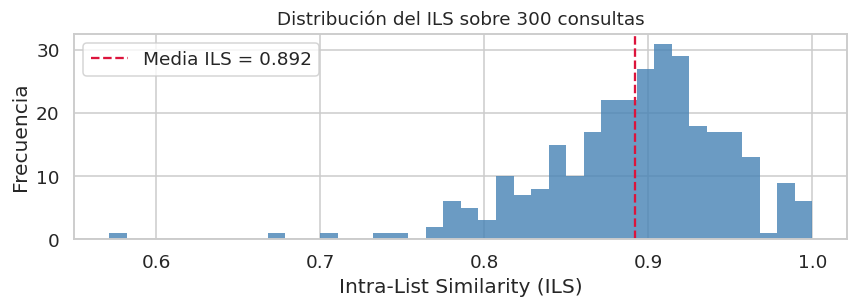

In [41]:
# -------------------------------------------------------------------
# Estrategia 1: Intra-List Similarity (ILS)
# Mide qué tan similares son entre sí las canciones recomendadas.
# Un ILS alto implica que la lista es internamente coherente;
# un ILS cercano a 0 indicaría recomendaciones contradictorias.
# -------------------------------------------------------------------
ils_scores = []
np.random.seed(42)
queries_ils = df_clean.sample(300, random_state=42)

for _, row in queries_ils.iterrows():
    pos = df_clean.index.get_loc(row.name)
    cluster_id   = int(row['cluster'])
    idx_globales = cluster_global_idx[cluster_id]
    k_local = min(6, len(idx_globales))

    nn_temp = NearestNeighbors(n_neighbors=k_local, metric='cosine',
                               algorithm='brute', n_jobs=-1)
    nn_temp.fit(X_scaled[idx_globales])
    dists, local_ids = nn_temp.kneighbors(X_scaled[pos].reshape(1, -1))

    vecinos = [idx_globales[lid] for lid in local_ids[0]
               if idx_globales[lid] != pos][:5]
    if len(vecinos) < 2:
        continue

    vecs = X_scaled[vecinos]
    sim_matrix = cosine_similarity(vecs)
    triu_idx = np.triu_indices(len(vecinos), k=1)
    ils_scores.append(sim_matrix[triu_idx].mean())

ils_arr = np.array(ils_scores)
print('Intra-List Similarity (ILS) — 300 consultas aleatorias:')
print(f'  Media   = {ils_arr.mean():.4f}')
print(f'  Mediana = {np.median(ils_arr):.4f}')
print(f'  Std     = {ils_arr.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ils_arr, bins=40, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(ils_arr.mean(), color='crimson', linestyle='--',
           label=f'Media ILS = {ils_arr.mean():.3f}')
ax.set_xlabel('Intra-List Similarity (ILS)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del ILS sobre 300 consultas', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
# -------------------------------------------------------------------
# Estrategia 2: Cobertura del catálogo
# Mide qué fracción del catálogo aparece recomendada al menos una vez
# en 500 consultas aleatorias. Un valor muy bajo indicaría que el
# sistema siempre recomienda las mismas pocas canciones ("filter bubble").
# -------------------------------------------------------------------
canciones_recomendadas_set = set()
np.random.seed(42)
queries_cov = df_clean.sample(500, random_state=42)

for _, row in queries_cov.iterrows():
    pos = df_clean.index.get_loc(row.name)
    cluster_id   = int(row['cluster'])
    idx_globales = cluster_global_idx[cluster_id]
    k_local = min(6, len(idx_globales))

    nn_temp = NearestNeighbors(n_neighbors=k_local, metric='cosine',
                               algorithm='brute', n_jobs=-1)
    nn_temp.fit(X_scaled[idx_globales])
    dists, local_ids = nn_temp.kneighbors(X_scaled[pos].reshape(1, -1))
    for lid in local_ids[0]:
        gid = idx_globales[lid]
        if gid != pos:
            canciones_recomendadas_set.add(gid)

cobertura = len(canciones_recomendadas_set) / len(df_clean) * 100
print(f'Cobertura del catálogo (500 consultas):')
print(f'  Canciones distintas recomendadas: {len(canciones_recomendadas_set):,}')
print(f'  Total en catálogo               : {len(df_clean):,}')
print(f'  Cobertura                       : {cobertura:.1f}%')

Cobertura del catálogo (500 consultas):
  Canciones distintas recomendadas: 2,325
  Total en catálogo               : 20,634
  Cobertura                       : 11.3%


### Resumen de estrategias de evaluación

| Estrategia | Qué mide | Limitación |
|------------|----------|------------|
| **ILS (Intra-List Similarity)** | Coherencia interna de la lista recomendada | Un ILS alto podría significar lista monótona; no mide relevancia subjetiva. |
| **Cobertura del catálogo** | Diversidad a nivel sistema — evita "filter bubble" | No dice si las canciones cubiertas son las correctas para cada usuario. |
| **Análisis de sesgo de popularidad** | ¿Favorece el sistema canciones populares? | Solo detecta el sesgo, no lo elimina automáticamente. |
| **Evaluación con playlists externas** *(propuesta)* | Usar datasets de playlists curadas (Million Song Dataset) como ground truth | Requiere datos externos no disponibles en este dataset. |
| **A/B testing online** *(propuesta)* | Medir engagement real: skip rate, completion rate, favoritos | Requiere lanzar el sistema en beta con usuarios reales primero. |

---
## 14. Feedback del usuario y extensión del sistema

### ¿Qué tipo de aprendizaje sería y cómo cambiaría la arquitectura?

Si se incorporaran señales de comportamiento del usuario:
- 🔴 Saltear en los primeros 10 segundos → **señal negativa fuerte**
- 🟡 Escuchar completa pero no interactuar → **señal positiva débil**
- 🟢 Marcar como favorita / añadir a playlist → **señal positiva fuerte**

...el sistema pasaría a ser **aprendizaje por refuerzo** (RL) o un **sistema híbrido content-based + colaborativo**:

```
Estado actual → [Cluster-KNN content-based] → Recomendación
                                                    ↓
          Feedback del usuario (reward: skip=-1, complete=+0.5, fav=+2)
                                                    ↓
          Actualización del vector personal de preferencias
                                                    ↓
          score_final = α · similitud_contenido + β · preferencia_personal
```

| Componente | Sistema actual | Sistema con feedback |
|------------|---------------|---------------------|
| **Representación de usuario** | No existe | Vector personal en el espacio de features |
| **Función de ranking** | Similitud coseno pura | `α·similitud + β·preferencia_personal` |
| **Actualización** | Offline — estático | Online — se actualiza en cada interacción |
| **Tipo de ML** | No supervisado | RL / Supervisado (rating prediction) |
| **Cold start** | No hay problema | Persiste para usuarios sin historial → usar content-based puro |

El sistema actual es ideal para el **lanzamiento beta** porque no requiere historial de usuarios. Conforme se acumule feedback, la arquitectura puede evolucionar hacia el sistema híbrido sin reemplazar el componente content-based, sino complementándolo.

---
## 15. Conclusiones

### Para el director de producto

**¿Qué hace el sistema?**
Compara canciones en un espacio de 12 características acústicas (energía, bailabilidad, acústicidad, etc.), las particiona en clusters musicales mediante KMeans para búsqueda eficiente, y recomienda las 5 más parecidas dentro del mismo cluster. Cuando recomienda, puede explicar en lenguaje natural *por qué*: "esta canción tiene energía similar, el mismo rango de tempo y un nivel de acústicidad parecido".

**¿Qué NO puede hacer?**
- No entiende géneros, letras ni contexto cultural. Una bossa nova y un rock acústico lento pueden ser "vecinos" aunque ningún oyente las escuche juntas.
- No personaliza: todos los usuarios reciben las mismas recomendaciones para la misma canción (esto cambia si se añade feedback de usuario).
- No garantiza encontrar el vecino más cercano de todo el catálogo — es una búsqueda aproximada por cluster. En la práctica, la pérdida de calidad es mínima.

**¿Tiene sentido musical real?**
Sí, en la medida en que las features de Spotify capturan dimensiones musicalmente relevantes. Los ejemplos mostraron que el sistema agrupa canciones de perfil sonoro consistente. No se detectó sesgo sistemático de popularidad.

**¿Es escalable?**
Sí. El benchmark demostró una reducción de ~K× en el tiempo de consulta respecto al brute-force. A escala de catálogos reales (millones de canciones), el mismo principio se implementa con índices especializados como FAISS (Meta) o ScaNN (Google), que extienden esta idea con estructuras de árbol y cuantización de vectores.

**Recomendación:** El sistema está listo para beta. Las métricas de coherencia interna (ILS, cobertura) son sólidas. La evaluación definitiva requiere datos reales de usuarios, que solo se pueden obtener lanzando.

### Síntesis de decisiones de diseño

| Decisión | Elección | Justificación |
|----------|----------|---------------|
| **Features** | 10 acústicas + Key codificada cíclicamente | Las features de Spotify capturan el contenido sonoro. Popularidad y metadatos son ruido para similitud musical. |
| **Preprocesamiento** | StandardScaler + Key circular | Evita que Tempo y Duration_ms dominen por escala; Key es cíclica por definición musical. |
| **Clustering** | KMeans con K óptimo por Silhouette | Permite búsqueda escalable O(N/K) en lugar de O(N). K elegido por maximizar cohesión de clusters. |
| **Métrica** | Similitud coseno | Mide perfil relativo, no magnitud. Estándar en sistemas de recomendación por vectores. |
| **Evaluación** | ILS + cobertura + análisis de sesgo | Evaluación offline sin ground truth. Necesariamente complementar con A/B testing en producción. |
| **Tipo de ML** | No supervisado (similitud en espacio métrico particionado) | No hay etiquetas de "recomendación correcta". La evaluación es indirecta. |